# N3 · Autoregressive Models
### *Explicit densities — factorize the joint: the GPT connection*

> **Status:** 🟡 *in progress* — **O3 ✅ · C3.1 ✅ · C3.2 ✅ · C3.3 ✅ · C3.4 open**. The first **2D** notebook (the 1D-default discipline finally escalates). Spine: an **autoregressive flow** — reuse N2's strictly-monotone scalar flow for each 1D conditional. Plan: §1 chain rule (exact, order-free) · §2 triangular Jacobian = N2's change-of-variables in 2D · §3 build & train · §4 ancestral sampling · §5 the GPT/masking connection + E3 exit-questions. Prereq: **N2 ✅**.

**The one new idea.** Stop modeling the joint `p(x)` in one shot. **Factorize** it into a chain of 1D conditionals — `p(x₁,x₂) = p(x₁)·p(x₂|x₁)` — and model each piece with machinery you already own (N2's flow). This is *exactly* how GPT models a sentence: one token at a time, each conditioned on the past.

$$p(x_1,x_2)\;=\;p(x_1)\,\underbrace{p(x_2\mid x_1)}_{\text{a 1D density that reshapes as }x_1\text{ moves}}$$

## §0 — Where we are, and why a second coordinate *now*

N1, N1b and N2 all modeled a **scalar** density `p(x)` directly — one plottable curve. N2 in particular won *exact* likelihood for a scalar `x` by warping a base density through an invertible map (change-of-variables).

But every real target — an image, a sentence, a molecule — is a **vector** `x=(x₁,…,x_D)`. New question: how do you put an *exact, tractable* density on a vector?

**The autoregressive answer — factorize.** The probability chain rule is an exact identity:
$$p(x_1,\dots,x_D)=\prod_{i=1}^{D} p\big(x_i \mid x_{<i}\big).$$
Model each 1D conditional `p(xᵢ | x_<i)` — a job you already know how to do (that's N2) — and multiply the pieces back. **No approximation:** the equality is exact for *any* density.

**Why this needs 2D (and N1/N2 didn't).** With a single coordinate the product has one factor, `p(x₁)=p(x₁)` — nothing to factorize, no "previous coordinates", no ordering. The mechanism is *vacuous* in 1D. **Two** coordinates is the smallest playground where a genuine conditional `p(x₂|x₁)` exists — the minimal "sequence" with a next element to predict. (This is the sanctioned escalation in the *1D-default discipline*: promote to 2D exactly when a mechanism is defined by interactions between ≥2 coordinates — and autoregressive factorization is one.)

**The 3 slots for N3** (the table we keep per notebook — what changed vs N2):

| slot | N2 (single flow) | **N3 (autoregressive flow)** |
|---|---|---|
| **1. family** (how we represent `p`) | one invertible warp of a scalar | a **chain** of conditionals, each a small flow |
| **2. is `log q(x)` exact & cheap?** | ✅ change-of-variables | ✅ a **sum** of the per-coordinate `log q`'s |
| **3. how we sample** | invert the map (bisection) | **ancestral**: draw `x₁`, then `x₂\|x₁` — one coordinate at a time |

Slot 1 is the new idea; slot 2 stays exact (so the N1 MLE loop survives untouched); slot 3 is where the new cost lands — and where GPT's token-by-token slowness comes from. First, let's *look* at the target we'll learn.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


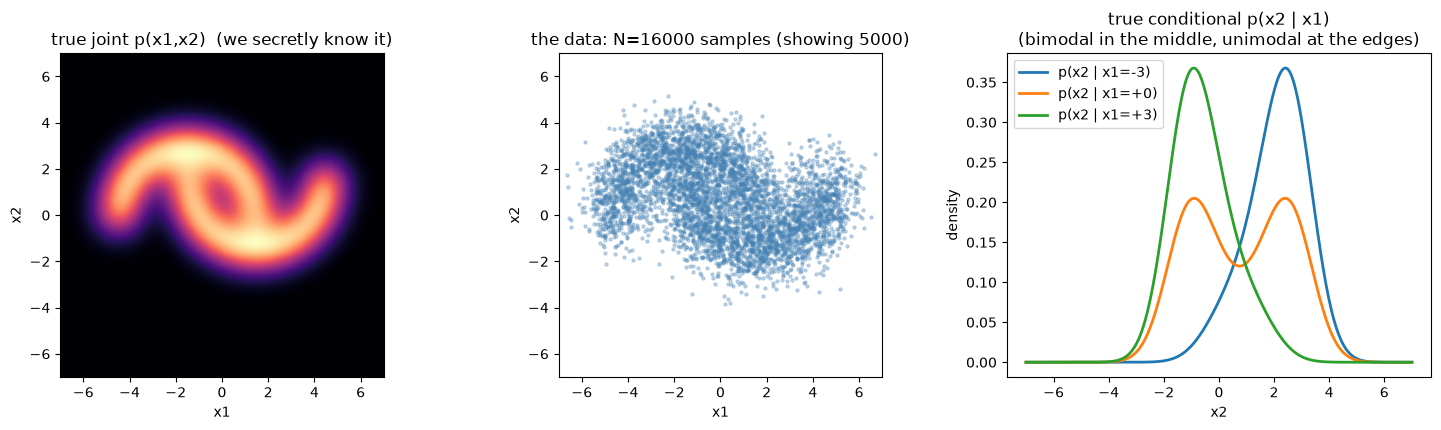

data shape (16000, 2).  Watch the ORANGE slice (x1=0): it has TWO bumps.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import jax, jax.numpy as jnp
from jax import random, vmap, grad
import optax
import numpy as np
import matplotlib.pyplot as plt
from toylab import two_moons, plot_density_2d, plot_samples_2d, kl_grid_2d

key = random.PRNGKey(0)
k_tr, k_va = random.split(key)
N = 16000                              # 2D needs a bigger sample budget than 1D — the N1b curse-of-dim, previewed
data = two_moons.sample(k_tr, N)       # (N, 2) — the bag of samples, ALL the model may see
val  = two_moons.sample(k_va, 4000)    # held-out, for honest scoring (the N1b lesson)

# We secretly know p(x1,x2) — used ONLY to grade and to draw "the truth".
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
plot_density_2d(two_moons.log_prob, lim=7, ax=ax[0], title="true joint p(x1,x2)  (we secretly know it)")
plot_samples_2d(data[:5000], lim=7, ax=ax[1], title=f"the data: N={N} samples (showing 5000)")

# the true conditional slices — the heart of the autoregressive story
x2g = jnp.linspace(-7, 7, 600)
for x1v, c in [(-3.0, "C0"), (0.0, "C1"), (3.0, "C2")]:
    cond = jnp.exp(two_moons.cond_x2_given_x1_log_prob(x2g, x1v))
    ax[2].plot(np.asarray(x2g), np.asarray(cond), c, lw=2, label=f"p(x2 | x1={x1v:+.0f})")
ax[2].set_title("true conditional p(x2 | x1)\n(bimodal in the middle, unimodal at the edges)")
ax[2].set_xlabel("x2"); ax[2].set_ylabel("density"); ax[2].legend()
fig.tight_layout(); plt.show()

print(f"data shape {tuple(data.shape)}.  Watch the ORANGE slice (x1=0): it has TWO bumps.")

## 🤔 O3 — opening objectives
*(answer in chat; we don't build until these hold)*

**O3.1 — Connect.** In N2 you computed an *exact* `log q(x)` for a **scalar** `x`. Now `x=(x₁,x₂)`.
- **(a)** Write the target `p(x₁,x₂)` as a product of two **1D** densities using one identity from probability — and *name* the identity.
- **(b)** Which piece of N2 machinery will you reuse to model *each* 1D factor?
- **(c)** Does the *exactness* of that product rely on any approximation, or on picking the "right" order (`x₁` then `x₂` vs `x₂` then `x₁`)?

**O3.2 — Predict-then-run.** Look at the right-hand panel — the true conditional `p(x₂|x₁)`. The orange slice (`x₁=0`) is **bimodal**; the edge slices are unimodal. Suppose we *lazily* modeled the conditional as a single Gaussian, `p(x₂|x₁)=𝒩(μ(x₁), σ(x₁))`, where `μ,σ` may be any functions of `x₁`.
**Predict:** on which slice does this fail, *what shape* does the best-fit Gaussian take there (where does it put its mass?), and what would that imply about samples drawn from that slice?

*Your answer (O3):*

- **O3.1 —** (a) p(x1,x2) = p(x1 given x2) p(x2) or p(x2 given x1) p(x1)- this is bayesian rule (b) now we will have 1D densities for each conditional x1 or x2 value we choose so will be conditional on one input. We will still use N2 normalizing flow? but that will change depending on the x1 or x2 value that we choose. (c) I think is irrelevant which x1 or x2 we pick to condition the density? 
- **O3.2 —** it will fail in the bimodal part cause it wont be able to capture the two bumps. It will be centered around the two peaks so we will capture a lot of false positives in the middle region

## §1 — The chain rule: *factorize* the joint

The autoregressive bet, in one identity. Pick an order for the coordinates — say `x₁` first, then `x₂` — and **predict each coordinate from the ones before it**:

$$p(x_1,x_2)\;=\;\underbrace{p(x_1)}_{\text{a 1D density}}\;\cdot\;\underbrace{p(x_2\mid x_1)}_{\text{a 1D density, one curve per }x_1}.$$

Both factors are **1D densities** — exactly the objects N2 already builds. The second is *conditional*: a different 1D curve for each value of `x₁` (the orange/blue/green slices you plotted in §0). So the whole plan is:

> **Model `p(x₁)` with one flow; model `p(x₂|x₁)` with a second flow whose shape is steered by `x₁`. Multiply. Done.**

**Two claims we'll nail in C3.1 — they're the entire reason this works:**

1. **It's exact.** Unlike a VAE's lower bound (N4) or a GAN's implicit density (N5), the chain rule is an *equality*, not a bound or an approximation. It holds for *any* joint density — that's what keeps N3 on "road (a), exact likelihood", alongside N2.
2. **Training decouples, and the loop doesn't change.** Take logs: `log p(x) = log p(x₁) + log p(x₂|x₁)`. The joint negative-log-likelihood is a **sum** of per-coordinate NLLs — so maximizing the joint likelihood is the *same N1 MLE loop*, now summed over coordinates. **Slot 2 stays ✅.**

**The GPT connection (the headline).** Swap "coordinate" for "token":
$$p(w_1,\dots,w_T)=\prod_{t=1}^{T} p\big(w_t \mid w_{<t}\big).$$
That product *is* a language model. GPT spends a giant Transformer on one job — producing `p(next token | tokens so far)`. Our two-coordinate toy is the same skeleton with `T=2` and a tiny flow in place of the Transformer. Everything you learn here — *exact likelihood*, *training by summed NLL*, *one-coordinate-at-a-time sampling* (slot 3, §4) — is literally how a language model is trained and sampled.

## 🤔 C3.1 — Derive the factorization (and its consequences)
*(the gate — **Derive**)*

**(a)** Starting from the **definition** of a conditional density, `p(x₂|x₁) := p(x₁,x₂)/p(x₁)`, derive `p(x₁,x₂)=p(x₁)·p(x₂|x₁)` in one line — and from that derivation say, in a sentence, **why it's exact** (no approximation, ever). Name the identity. *(Careful: it is not Bayes' rule — Bayes inverts a conditional, `p(a|b)=p(b|a)p(a)/p(b)`.)*

**(b)** Take logs of both sides: `log p(x) = log p(x₁) + log p(x₂|x₁)`. We train by minimizing the mean NLL over the data. Explain why this **sum** lets us train the two flows **together in one loop by just adding their NLLs** — i.e. why there's no extra coupling term being swept under the rug.

**(c)** Both `(x₁ then x₂)` and `(x₂ then x₁)` are *exactly* correct (you said as much in O3.1c). So order can't change *correctness*. Give **one concrete reason** a finite-capacity autoregressive *model* might still fit better under one ordering than the other.

*Your answer (C3.1):*

- **(a)** easy to prove no? p(x2 given x1) p(x1) gives you p(x1, x2) if we do that in both orders and equal we get bayes formula
- **(b)** I guess because they are two separate densities? 
- **(c)** I guess you might do better with one order or the other depending on the two densities? I cant think of an example but I assume that you want simple densities first ? not sure how you assess that 

## §2 — The triangular Jacobian: the *geometric* twin of the chain rule

§1 gave the chain rule as a fact about *probabilities*. Now watch the **exact same thing** fall out of N2's geometry — change-of-variables — once we go to 2D. This is the "one new idea" of N3, shown rather than asserted.

**N2 recap (scalar).** A normalizing map `f: x → z` gave `log q(x) = log p_Z(f(x)) + log|f'(x)|`. The `|f'(x)|` is the local stretch factor that conserves mass.

**The 2D version.** For an invertible map `f: (x₁,x₂) → (z₁,z₂)`, multivariate change-of-variables replaces the scalar derivative with the **Jacobian determinant**:
$$\log q(\mathbf{x}) = \log p_Z(f(\mathbf{x})) + \log\big|\det J_f(\mathbf{x})\big|,\qquad J_f=\frac{\partial(z_1,z_2)}{\partial(x_1,x_2)}.$$

**Now make `f` autoregressive** — each output sees only the inputs *up to its index*:
$$z_1=f_1(x_1),\qquad z_2=f_2(x_2;\,x_1).$$
(`z₁` warps `x₁` alone; `z₂` warps `x₂`, *steered by* `x₁` — that steering is the conditional.) Its Jacobian:
$$J_f=\begin{bmatrix}\dfrac{\partial z_1}{\partial x_1} & \dfrac{\partial z_1}{\partial x_2}\\[1.1em]\dfrac{\partial z_2}{\partial x_1} & \dfrac{\partial z_2}{\partial x_2}\end{bmatrix}=\begin{bmatrix}\dfrac{\partial z_1}{\partial x_1} & \mathbf{0}\\[1.1em]\dfrac{\partial z_2}{\partial x_1} & \dfrac{\partial z_2}{\partial x_2}\end{bmatrix}.$$

The top-right entry is **0** because `z₁` doesn't depend on `x₂` — autoregressive structure ⇒ **lower-triangular** Jacobian. And a triangular determinant is just the **product of the diagonal**:
$$\det J_f=\frac{\partial z_1}{\partial x_1}\cdot\frac{\partial z_2}{\partial x_2}\quad(\text{the off-diagonal }\tfrac{\partial z_2}{\partial x_1}\textbf{ never enters}).$$

So:
$$\log q(\mathbf{x})=\underbrace{\Big[\log p_Z(z_1)+\log\big|\tfrac{\partial z_1}{\partial x_1}\big|\Big]}_{\log q(x_1)}+\underbrace{\Big[\log p_Z(z_2)+\log\big|\tfrac{\partial z_2}{\partial x_2}\big|\Big]}_{\log q(x_2\mid x_1)}.$$

**That is the chain rule.** The triangular-Jacobian change-of-variables and the §1 factorization are *the same object*: autoregressive structure (each `zᵢ` sees only `x_{≤i}`) ⇒ triangular `J` ⇒ `log|det J|` is a **sum** ⇒ `log q` splits into per-coordinate conditionals. Two roads, one destination.

**Why "triangular" is the headline and not a footnote.** A general `D×D` determinant costs `O(D³)` — and change-of-variables needs it *every training step*. A triangular determinant is a product of `D` diagonal entries: **`O(D)`**. That cheapness is exactly what lets autoregressive flows (and the coupling flows of RealNVP) scale to `D=784` pixels or thousands of tokens. The off-diagonal `∂z₂/∂x₁` is free to be arbitrarily expressive (it's the conditioning!) — it just costs nothing in the determinant.

## 🤔 C3.2 — Hand-compute the triangular determinant
*(the gate — **Hand-compute**, do it on tiny numbers)*

Take this concrete affine normalizing map (3 small numbers):
$$z_1 = 2x_1,\qquad z_2 = 3x_2 + 5x_1.$$

**(a)** Write the `2×2` Jacobian `J = ∂(z₁,z₂)/∂(x₁,x₂)`. Which entry is **0**, and *why* (one phrase)?

**(b)** Compute `det J` **by hand**. Show explicitly that the off-diagonal coefficient `5` does **not** appear in the answer.

**(c) — Connect.** With base `z ~ 𝒩(0, I)`, this map defines some `q(x₁,x₂)`. Look at the conditional it implies: as a function of `x₂` for fixed `x₁`, what *family* is `p(x₂|x₁)`, and how does `x₁` enter it? Then tie it back to O3.2: can this affine map produce the **bimodal** middle slice of two-moons — yes or no, and what does that tell us we'll need in §3?

*Your answer (C3.2):*

- **(a)** (2 0 ; 5 3)
- **(b)** det is 6 is the diagonal product
- **(c)** so what we are doing is we are basically piecing out the complexity of the joint distribution one dimension by one dimension using the chain rule. We fit a transformation per each 1D density and we autoregressively get the actual joint probability. It is smart - and we do it in a way that det of J is actually   

## §3 — Build the autoregressive flow: same MLE loop, factorized family (slot 1)

C3.1–C3.2 settled the math; now the build. **Two flows**, each the strictly-monotone scalar map from N2:

- **`p(x₁)` — an ordinary N2 flow** `f₁: x₁→z₁` with free parameters `θ₁`. (N2's slot 1, verbatim.)
- **`p(x₂|x₁)` — a *conditional* N2 flow** `f₂: x₂→z₂` whose parameters are **emitted by a tiny hypernetwork `MLP(x₁)`**. *That* is the conditioning: a different warp of `x₂` for every `x₁`, so the conditional can morph from unimodal (edges) to bimodal (middle).

Each flow is N2's transform `f(y)=e^{a}y+b+\sum_k \mathrm{softplus}(g_k)\tanh(e^{u_k}y+v_k)` (strictly increasing ⇒ invertible), and we read `f'` straight from **`jax.grad`** — the N2 lesson, reused. The per-coordinate log-densities are N2's change-of-variables; we **add** them (C3.1b) and minimize the mean NLL with the *identical* Optax Adam loop. **Nothing about the objective is new — only slot 1.**

*(2D detail: we train on `N=16000` with a little weight decay. A flexible flow + hypernetwork can overfit the low-density tails into spurious spikes; more data + mild regularization keeps the conditionals smooth. "Need more data in higher D" is N1b's curse of dimensionality, knocking again.)*

val NLL = 4.1699    H(p) = 4.1181    gap = 0.0518
grid KL(p||q) = 0.0360      q integrates to 0.9894


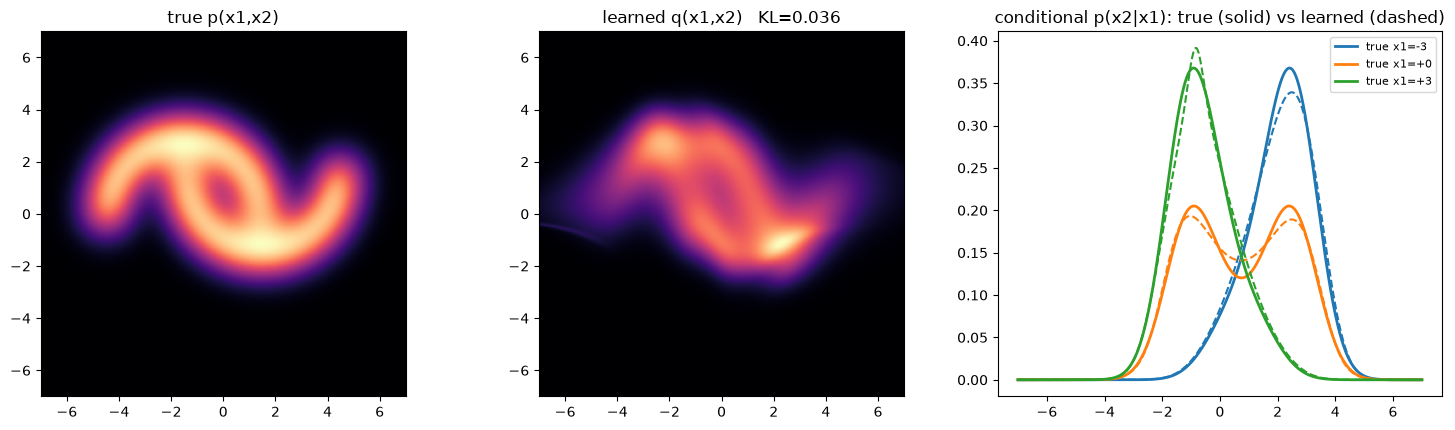

total params = 412   (flow theta1 = 14, hypernetwork = the rest)


In [2]:
# ===== N3 autoregressive flow: p(x1) free flow + p(x2|x1) flow conditioned by MLP(x1) =====
K, H_HID = 4, 24                       # bumps per flow ; hypernetwork hidden width
P = 2 + 3 * K                          # params of ONE monotone flow: a, b, g[K], u[K], v[K]
LOG2PI = jnp.log(2 * jnp.pi)

def log_base(z): return -0.5 * LOG2PI - 0.5 * z ** 2     # standard-normal base p_Z

def flow(y, th):                       # N2 strictly-monotone scalar map f(y); th:(P,) -> scalar
    a, b = th[0], th[1]
    g = th[2:2+K]; u = th[2+K:2+2*K]; v = th[2+2*K:2+3*K]
    #e^a * y + b + sum(softplus(g) * tanh(e^u * y + v))
    return jnp.exp(a) * y + b + jnp.sum(jax.nn.softplus(g) * jnp.tanh(jnp.exp(u) * y + v))

dflow = grad(flow, argnums=0)          # f'(y) via autodiff — the N2 lesson, reused

def hyper(phi, x1):                    # the hypernetwork: scalar x1 -> (P,) params of the conditional flow
    h = jnp.tanh(phi["W1"] @ jnp.atleast_1d(x1) + phi["b1"])
    return phi["W2"] @ h + phi["b2"]

FLOW0 = jnp.concatenate([jnp.zeros(2), jnp.full(K, -4.0), jnp.zeros(K), jnp.linspace(-2, 2, K)])  # ~identity init
def init(key):
    kf, k1, k2 = random.split(key, 3)
    return {"theta1": FLOW0 + 0.01 * random.normal(kf, (P,)),
            "phi": {"W1": 0.5 * random.normal(k1, (H_HID, 1)), "b1": jnp.zeros(H_HID),
                    "W2": 0.01 * random.normal(k2, (P, H_HID)), "b2": FLOW0}}   # conditional starts ~identity

def log_q(params, X):                  # log q(x1,x2) = log q(x1) + log q(x2|x1)   <- the chain rule (C3.1)
    x1, x2 = X[:, 0], X[:, 1]
    th1 = params["theta1"]
    z1 = vmap(flow, (0, None))(x1, th1); d1 = vmap(dflow, (0, None))(x1, th1)
    th2 = vmap(hyper, (None, 0))(params["phi"], x1)        # (n, P): a DIFFERENT flow per x1
    z2 = vmap(flow)(x2, th2);            d2 = vmap(dflow)(x2, th2)
    return (log_base(z1) + jnp.log(d1)) + (log_base(z2) + jnp.log(d2))

nll = lambda params, X: -jnp.mean(log_q(params, X))

params = init(random.PRNGKey(10))
opt = optax.adamw(optax.cosine_decay_schedule(2e-3, 5000), weight_decay=8e-3)
state = opt.init(params)
@jax.jit
def step(params, state, X):
    loss, g = jax.value_and_grad(nll)(params, X)
    updates, state = opt.update(g, state, params)
    return optax.apply_updates(params, updates), state, loss
for e in range(5000):
    params, state, loss = step(params, state, data)

# ---- grade: held-out NLL vs the entropy floor, and exact 2D grid-KL ----
Hp = float(-jnp.mean(two_moons.log_prob(two_moons.sample(random.PRNGKey(123), 200_000))))   # H(p) = -E_p[log p]
lim, G = 7.0, 300
axis = jnp.linspace(-lim, lim, G)
GX1, GX2 = jnp.meshgrid(axis, axis); gpts = jnp.stack([GX1.ravel(), GX2.ravel()], 1)
q_grid = jnp.exp(log_q(params, gpts)).reshape(G, G)
p_grid = jnp.exp(two_moons.log_prob(gpts)).reshape(G, G)
KL = float(kl_grid_2d(p_grid, q_grid, axis))
vnll = float(nll(params, val))
print(f"val NLL = {vnll:.4f}    H(p) = {Hp:.4f}    gap = {vnll - Hp:.4f}")
print(f"grid KL(p||q) = {KL:.4f}      q integrates to {float(q_grid.sum() * (axis[1]-axis[0])**2):.4f}")

# ---- the money plot: learned joint + conditional slices vs truth ----
def q_cond(params, x1v, x2grid):       # learned p(x2|x1) at a fixed x1
    th2 = hyper(params["phi"], jnp.array(x1v))
    z2 = vmap(flow, (0, None))(x2grid, th2); d2 = vmap(dflow, (0, None))(x2grid, th2)
    return jnp.exp(log_base(z2) + jnp.log(d2))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].imshow(np.asarray(p_grid), origin="lower", extent=[-lim,lim,-lim,lim], cmap="magma", aspect="equal"); ax[0].set_title("true p(x1,x2)")
ax[1].imshow(np.asarray(q_grid), origin="lower", extent=[-lim,lim,-lim,lim], cmap="magma", aspect="equal"); ax[1].set_title(f"learned q(x1,x2)   KL={KL:.3f}")
for x1v, c in [(-3.0,"C0"), (0.0,"C1"), (3.0,"C2")]:
    ax[2].plot(np.asarray(x2g), np.asarray(jnp.exp(two_moons.cond_x2_given_x1_log_prob(x2g, x1v))), c, lw=2, label=f"true x1={x1v:+.0f}")
    ax[2].plot(np.asarray(x2g), np.asarray(q_cond(params, x1v, x2g)), c + "--", lw=1.5)
ax[2].set_title("conditional p(x2|x1): true (solid) vs learned (dashed)"); ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()
n_params = sum(int(np.prod(np.asarray(a).shape)) for a in jax.tree_util.tree_leaves(params))
print(f"total params = {n_params}   (flow theta1 = {P}, hypernetwork = the rest)")

### §3 — what you should see *(verified in `.venv`, seeds as written)*

| metric | value | reading |
|---|---|---|
| **val NLL** | **4.170** | vs entropy floor **H(p)=4.118** → gap **0.052** (near-perfect, as N2's NLL≈H(p)) |
| **grid KL(p‖q)** | **0.036** | exact 2D KL; the flow bends into both moons |
| **∫∫ q** | **0.989** | log-det self-normalizes (≈1 up to grid truncation) |
| **params** | **412** | a *tiny* model — still compact (the N1b weakness we fixed) |

The **learned joint** is two moons; the **conditional slices** (dashed) sit on the truth (solid): **bimodal at `x₁=0`, unimodal at the edges**. The autoregressive flow captured exactly the structure a single Gaussian couldn't — which is what C3.3 makes you prove.

## 🤔 C3.3 — Break-it: cripple the conditional
*(the gate — **Predict-then-run**; commit before running the next cell)*

You've watched the AR flow nail the bimodal middle. Now we **degrade slot 1**: keep `p(x₁)` as the same flow, but replace the conditional *flow* with a single **Gaussian** `p(x₂|x₁)=𝒩(μ(x₁), σ(x₁))`, with `μ,σ` emitted by an MLP(x₁). (This is C3.2(c)'s linear-Gaussian conditional, now with `μ,σ` free *nonlinear* functions of `x₁` — so we're not even handicapping the conditioning, only the conditional's *shape*.)

**Predict, then run the reveal cell:**
- **(a)** Which `x₁`-slice does it fail on, and what *shape* does its learned `p(x₂|x₁)` take there — where does its mass go? (Sharpen your O3.2 answer.)
- **(b)** Will `p(x₁)` and the *edge* (unimodal) slices still be fine? Why?
- **(c)** Predict the **grid KL** vs the flow's **0.036** — bigger or smaller, and roughly by how much?

*Your answer (C3.3):*

- **(a)**
- **(b)**
- **(c)**

[Gaussian conditional]  val NLL = 4.2133   (flow: 4.1699,  H(p): 4.1181)
[Gaussian conditional]  grid KL = 0.0702    (flow: 0.0360  ->  1.9x worse)


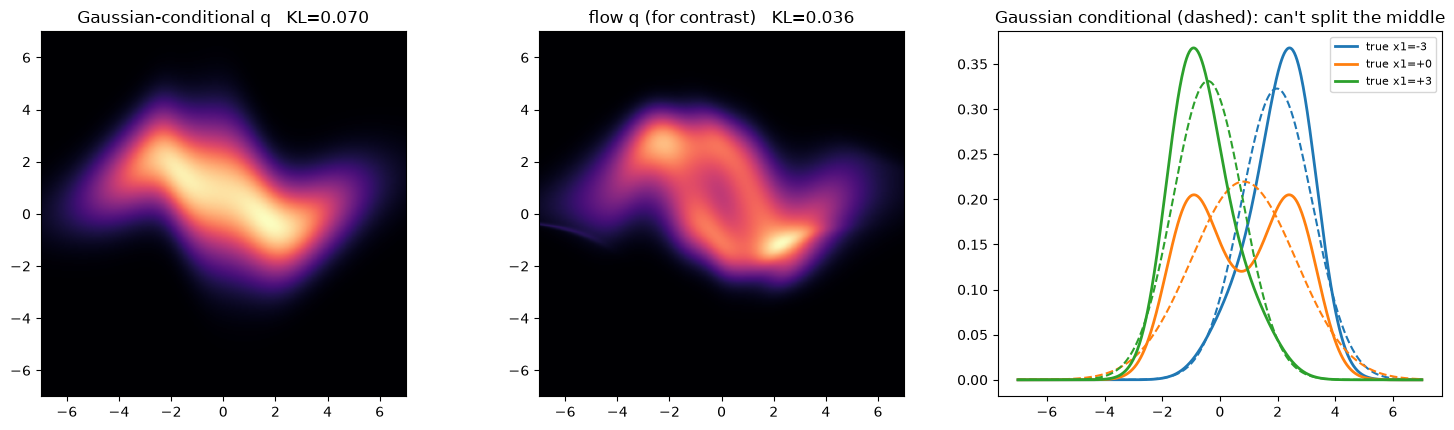

In [3]:
# ===== break-it reveal: same p(x1) flow, but conditional = single Gaussian N(mu(x1), sigma(x1)) =====
def init_gauss(key):
    kf, k1, k2 = random.split(key, 3)
    return {"theta1": FLOW0 + 0.01 * random.normal(kf, (P,)),                    # SAME p(x1) flow
            "phi": {"W1": 0.5 * random.normal(k1, (H_HID, 1)), "b1": jnp.zeros(H_HID),
                    "W2": 0.01 * random.normal(k2, (2, H_HID)), "b2": jnp.zeros(2)}}   # -> (mu, log_sigma)

def log_q_gauss(params, X):
    x1, x2 = X[:, 0], X[:, 1]
    th1 = params["theta1"]
    z1 = vmap(flow, (0, None))(x1, th1); d1 = vmap(dflow, (0, None))(x1, th1)
    out = vmap(hyper, (None, 0))(params["phi"], x1)       # (n, 2) = (mu, log_sigma)
    mu, log_sig = out[:, 0], out[:, 1]
    lq2 = -0.5 * LOG2PI - log_sig - 0.5 * ((x2 - mu) / jnp.exp(log_sig)) ** 2     # log N(x2; mu, sigma)
    return (log_base(z1) + jnp.log(d1)) + lq2

nll_g = lambda params, X: -jnp.mean(log_q_gauss(params, X))
pg = init_gauss(random.PRNGKey(11))
optg = optax.adamw(optax.cosine_decay_schedule(2e-3, 5000), weight_decay=8e-3); sg = optg.init(pg)
@jax.jit
def step_g(params, state, X):
    loss, grd = jax.value_and_grad(nll_g)(params, X)
    updates, state = optg.update(grd, state, params)
    return optax.apply_updates(params, updates), state, loss
for e in range(5000):
    pg, sg, _ = step_g(pg, sg, data)

qg_grid = jnp.exp(log_q_gauss(pg, gpts)).reshape(G, G)
KL_g = float(kl_grid_2d(p_grid, qg_grid, axis))
print(f"[Gaussian conditional]  val NLL = {float(nll_g(pg, val)):.4f}   (flow: {vnll:.4f},  H(p): {Hp:.4f})")
print(f"[Gaussian conditional]  grid KL = {KL_g:.4f}    (flow: {KL:.4f}  ->  {KL_g/KL:.1f}x worse)")

def q_cond_gauss(params, x1v, x2grid):
    out = hyper(params["phi"], jnp.array(x1v)); mu, log_sig = out[0], out[1]
    return jnp.exp(-0.5 * LOG2PI - log_sig - 0.5 * ((x2grid - mu) / jnp.exp(log_sig)) ** 2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].imshow(np.asarray(qg_grid), origin="lower", extent=[-lim,lim,-lim,lim], cmap="magma", aspect="equal"); ax[0].set_title(f"Gaussian-conditional q   KL={KL_g:.3f}")
ax[1].imshow(np.asarray(q_grid), origin="lower", extent=[-lim,lim,-lim,lim], cmap="magma", aspect="equal"); ax[1].set_title(f"flow q (for contrast)   KL={KL:.3f}")
for x1v, c in [(-3.0,"C0"), (0.0,"C1"), (3.0,"C2")]:
    ax[2].plot(np.asarray(x2g), np.asarray(jnp.exp(two_moons.cond_x2_given_x1_log_prob(x2g, x1v))), c, lw=2, label=f"true x1={x1v:+.0f}")
    ax[2].plot(np.asarray(x2g), np.asarray(q_cond_gauss(pg, x1v, x2g)), c + "--", lw=1.5)
ax[2].set_title("Gaussian conditional (dashed): can't split the middle"); ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

### §3 break-it — what you should see *(verified)*

| model | val NLL | grid KL(p‖q) |
|---|---|---|
| AR **flow** conditional | **4.170** | **0.036** |
| **Gaussian** conditional | **4.213** | **0.070**  (≈ **2× worse**) |

The Gaussian-conditional `q` **smears the two moons into a single banana** — at every `x₁` its `p(x₂|x₁)` is one bump, so it parks that bump in the **valley between the true peaks** on the `x₁=0` slice (mass in the gap, on *neither* moon — your O3.2 prediction, made literal). `p(x₁)` and the unimodal edge slices are fine; the damage is exactly and only where the true conditional is **multimodal**. The fix isn't a bigger conditioner — it's a richer *conditional family*, i.e. a flow. (This is N1→N2 again, now living inside `p(x₂|x₁)`.)

## §4 — Ancestral sampling: slot 3 pays the bill

Notice what training *never* needed: an inverse. Slot 2 was parallel — one `log_q` call scored **every conditional of every datapoint at once**, because during training the prefix `x₁` comes *from the data*; you never have to generate it. (In language modeling this has a name: **teacher forcing**.)

Sampling has no data to lean on. The chain rule now reads as a *recipe* — **ancestral sampling**:

1. draw `z₁, z₂ ~ 𝒩(0,1)` i.i.d. — parallel, cheap;
2. `x₁ = f₁⁻¹(z₁)` — N2's bisection, verbatim (monotone ⇒ unique root);
3. **only now** can `MLP(x₁)` emit `θ₂` — *the conditional flow doesn't exist until its prefix does*;
4. `x₂ = f₂⁻¹(z₂; θ₂)`.

Step 3 is the structural bottleneck: **`x₂` cannot start until `x₁` has landed.** In `D` dimensions that's `D` sequential inversions. It is not an implementation choice we could optimize away — the *family itself* is defined left-to-right, so generation is too. This is exactly why GPT emits one token at a time (and why your chat replies stream): same asymmetry, **training parallel · generation sequential**, baked into autoregressive-ness. On the capstone's six axes, this is where **sampling speed** takes its hit.


## 🤔 C3.4 — Predict-then-run: the sampler on trial
*(the gate — commit before running the sampler cell)*

- **(a)** **Hand-compute the precision.** 60 bisection halvings of the bracket `[-20, 20]` localize the root to `40·2⁻⁶⁰ ≈ 4·10⁻¹⁷` … yet N2 measured a round-trip error `max|f(x̂)−z| ≈ 10⁻⁶`. Reconcile the two numbers — what actually sets the floor, and roughly what round-trip error do you predict here?
- **(b)** **Predict the middle slice.** Among samples with `|x₁| < 0.5`, what fraction should land on the *upper* moon (`x₂ > 0`)? Read it off the orange `x₁=0` slice in the §3 money plot — the relative *areas* of its two bumps.
- **(c)** **The trap.** After running you'll see the sample-marginal **W1 on `x₁` ≈ 0.22** — about **5× the real-vs-real floor** (~0.04 at n=4000) — while the joint **grid KL = 0.036** looked near-perfect. Two suspects: (i) the bisection sampler is producing wrong samples, (ii) the model's own marginal `q(x₁)` is slightly off and the sampler is faithfully reporting it. Name the **one-line check that acquits or convicts the sampler**, and place your bet.


*Your answer (C3.4):*

- **(a)**
- **(b)**
- **(c)**


round-trip  max|f1(x1)-z1| = 7.2e-07   max|f2(x2;x1)-z2| = 1.1e-06
samples mean (+0.042, +0.712)   std (2.796, 1.654)
data    mean (+0.033, +0.731)   std (2.805, 1.631)


sample-W1 marginal x1: model-vs-true = 0.217   real-vs-real floor = 0.043
sample-W1 marginal x2: model-vs-true = 0.035   real-vs-real floor = 0.029


middle slice |x1|<0.5: frac upper moon = 0.626   (true = 0.600, from a 200k draw)


EXACT grid-W1(p(x1), q(x1)) = 0.179   -> the gap is the MODEL's marginal, not the sampler


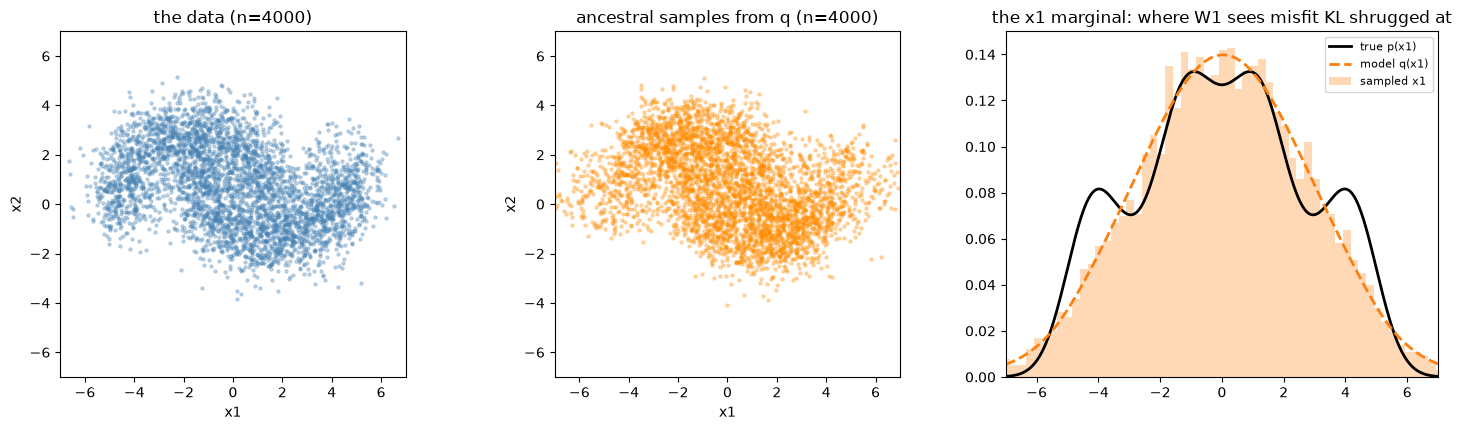

In [4]:
# ===== ancestral sampling: draw z in parallel, invert the chain ONE COORDINATE AT A TIME =====
from functools import partial
from toylab.metrics import wasserstein1, wasserstein1_cdf

def f_inv(z, th, lo=-20.0, hi=20.0, iters=60):   # N2's bisection, verbatim: monotone f => unique root
    def body(_, bracket):
        lo, hi = bracket
        mid = 0.5 * (lo + hi)
        go_right = flow(mid, th) < z             # f increasing: root is right of mid -> move ONE edge
        return (jnp.where(go_right, mid, lo), jnp.where(go_right, hi, mid))
    lo, hi = jax.lax.fori_loop(0, iters, body, (jnp.array(lo), jnp.array(hi)))
    return 0.5 * (lo + hi)

@partial(jax.jit, static_argnums=2)
def sample_ar(params, key, n):
    kz1, kz2 = random.split(key)
    z1 = random.normal(kz1, (n,)); z2 = random.normal(kz2, (n,))     # base draws: parallel, cheap
    x1 = vmap(f_inv, (0, None))(z1, params["theta1"])                # (1) x1 = f1^{-1}(z1)
    th2 = vmap(hyper, (None, 0))(params["phi"], x1)                  # (2) prefix -> conditional params: WAITS for x1
    x2 = vmap(f_inv)(z2, th2)                                        # (3) x2 = f2^{-1}(z2 ; x1)
    return jnp.stack([x1, x2], 1), (z1, z2, th2)

n_s = 4000
S, (z1, z2, th2) = sample_ar(params, random.PRNGKey(42), n_s)

# ---- C3.4(c): acquit or convict the sampler — the round trip ----
rt1 = float(jnp.max(jnp.abs(vmap(flow, (0, None))(S[:, 0], params["theta1"]) - z1)))
rt2 = float(jnp.max(jnp.abs(vmap(flow)(S[:, 1], th2) - z2)))
print(f"round-trip  max|f1(x1)-z1| = {rt1:.1e}   max|f2(x2;x1)-z2| = {rt2:.1e}")

# ---- score the samples ----
print(f"samples mean ({float(S[:,0].mean()):+.3f}, {float(S[:,1].mean()):+.3f})   std ({float(S[:,0].std()):.3f}, {float(S[:,1].std()):.3f})")
print(f"data    mean ({float(data[:,0].mean()):+.3f}, {float(data[:,1].mean()):+.3f})   std ({float(data[:,0].std()):.3f}, {float(data[:,1].std()):.3f})")
tA = two_moons.sample(random.PRNGKey(7), n_s); tB = two_moons.sample(random.PRNGKey(8), n_s)
for j, nm in [(0, "x1"), (1, "x2")]:
    w  = float(wasserstein1(np.asarray(S[:, j]), np.asarray(tA[:, j])))
    fl = float(wasserstein1(np.asarray(tB[:, j]), np.asarray(tA[:, j])))
    print(f"sample-W1 marginal {nm}: model-vs-true = {w:.3f}   real-vs-real floor = {fl:.3f}")
mid = jnp.abs(S[:, 0]) < 0.5
print(f"middle slice |x1|<0.5: frac upper moon = {float(jnp.mean(S[mid][:,1] > 0)):.3f}   (true = 0.600, from a 200k draw)")

# ---- the sharper ruler: EXACT marginal W1 on a grid (no sampling noise) — settles C3.4(c) ----
xg = jnp.linspace(-9, 9, 2001)
q_m1 = jnp.exp(vmap(lambda x: log_base(flow(x, params["theta1"])) + jnp.log(dflow(x, params["theta1"])))(xg))
p_m1 = jnp.exp(two_moons.marginal_x1_log_prob(xg))
print(f"EXACT grid-W1(p(x1), q(x1)) = {float(wasserstein1_cdf(np.asarray(p_m1), np.asarray(q_m1), np.asarray(xg))):.3f}"
      f"   -> the gap is the MODEL's marginal, not the sampler")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
plot_samples_2d(data[:n_s], lim=7, ax=ax[0], title=f"the data (n={n_s})")
plot_samples_2d(S, lim=7, ax=ax[1], color="darkorange", title=f"ancestral samples from q (n={n_s})")
ax[2].plot(np.asarray(xg), np.asarray(p_m1), "k", lw=2, label="true p(x1)")
ax[2].plot(np.asarray(xg), np.asarray(q_m1), "C1--", lw=2, label="model q(x1)")
ax[2].hist(np.asarray(S[:, 0]), bins=80, density=True, alpha=0.3, color="C1", label="sampled x1")
ax[2].set_xlim(-7, 7); ax[2].set_title("the x1 marginal: where W1 sees misfit KL shrugged at")
ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()


### §4 — what you should see *(verified in `.venv`, seeds as written)*

| check | value | reading |
|---|---|---|
| round-trip `max\|f−z\|` | **7·10⁻⁷ / 1.1·10⁻⁶** | float32's floor, not bisection's — the **sampler is acquitted** |
| sample mean / std | (+0.04, +0.71) / (2.80, 1.65) | data: (+0.03, +0.73) / (2.81, 1.63) — moments match |
| sample-W1, `x₂` marginal | **0.035** (floor 0.029) | at the noise floor — as good as real-vs-real |
| sample-W1, `x₁` marginal | **0.217** (floor 0.043) | **5× the floor — real misfit**, C3.4(c)'s trap |
| **exact** grid-W1 `p(x₁)` vs `q(x₁)` | **0.179** | no sampling noise in this number → **the model's `q(x₁)` is convicted** |
| middle slice, frac upper moon | **0.626** (true 0.600) | the sampler *splits the bimodal slice* — C3.3's win, now in samples |

Two lessons close the section:

- **(a) is float32's fault, not bisection's.** `40·2⁻⁶⁰ ≈ 4·10⁻¹⁷` is exact-arithmetic fantasy; single precision carries ~7 significant digits, so evaluating `f` itself is only good to ~`10⁻⁶`–`10⁻⁷`. The bisection hits the *representable* answer in well under 60 steps — same `~10⁻⁶` we measured in N2.
- **The verdict on (c): different rulers disagree, and both are right.** The round trip acquits the sampler (it inverts *this model* to machine precision); the exact grid-W1 of **0.179** convicts the model's own 14-param `f₁` — it misplaces a little `x₁`-mass, which W1 (mass × *distance moved*, in x-units) surfaces but grid-KL (mass × *log-ratio*) barely prices, and the eye test can't see against σ(x₁) ≈ 2.8. That is N0's lesson recurring: **a scalar score is a choice of ruler**. If we cared, the fix is capacity where the misfit lives — a bigger `K` for `f₁` — the kind of budgeted call the capstone will make you defend.


## §5 — The GPT connection, made literal (+ the recap)

You have now built, trained, and sampled the *exact* mechanism inside GPT — at `D=2`, with flows instead of softmaxes. The dictionary:

| our N3 build | GPT |
|---|---|
| coordinate `xᵢ` | token `i` |
| ordering `x₁ → x₂` | left-to-right token order |
| hypernetwork `MLP(x₁) → θ₂` | transformer: prefix → next-token logits |
| conditional flow `q(x₂\|θ₂)` | softmax over the vocabulary |
| `log q = Σᵢ log q(xᵢ\|x_{<i})` (C3.1) | sum of next-token log-probs = the LM loss |
| training on data prefixes, all conditionals in parallel | **teacher forcing** behind a **causal mask** |
| ancestral sampling, one inversion per coordinate (§4) | token-by-token generation (why LLM output *streams*) |

**The one trick we skipped — parameter sharing.** At `D=2` we could afford a private hypernetwork for the one conditional. At `D=784` (an MNIST image) you do *not* build 783 networks: **one shared network computes all `D` conditionals in a single pass**, with **masks** enforcing that the unit predicting `xᵢ` sees only `x_{<i}` — that's MADE / PixelCNN / causal attention, and it's the *whole* architectural content of "autoregressive at scale". Stack several masked AR flows and you have **MAF**; define the flow in the other direction so *sampling* is the one-pass side (paying with slow density) and you have **IAF**. Same chain rule, different choice of which direction hurts.

**The 3 slots, closed out** — family: a *chain* of 1D conditionals, each an N2 flow, glued by the chain rule (exact, no approximation); density: still exact — a **sum** of per-coordinate change-of-variables terms (triangular Jacobian, C3.2); sampler: **ancestral** — `D` sequential inversions.

**Capstone axes preview:** Exact likelihood **✅✅** (it's a sum of exact 1D terms) · Fidelity / mode coverage **✅** (nailed the bimodal conditional a Gaussian couldn't, §3) · Training stability **✅** (plain MLE, no adversary) · **Sampling speed ⚠️⚠️** (sequential in `D` — GPT's generation latency, our §4) · Data efficiency **⚠️** (16k samples for a clean 2D fit; N1b's curse, one dimension in).

---

### 🤔 E3 — exit questions *(open — think on paper; ungraded)*

- **E3.1 (Break-it).** The chain rule is order-free *in principle*: `p(x₂)·p(x₁|x₂)` is just as exact. Rebuild the model that way *in your head*: what does the slice `p(x₁|x₂=0)` look like — how many modes? Would our `K=4` conditional flow still cope? What property of a *target* makes ordering matter in practice even though the identity doesn't care?
- **E3.2 (Scale).** For `D=784` pixels, say precisely what the mask in MADE/PixelCNN must enforce, and why *one* shared network evaluating all 784 conditionals in parallel doesn't violate the chain rule's "only the past" constraint at *training* time — yet buys nothing at *sampling* time.
- **E3.3 (Connect forward).** Our density evaluation is one parallel pass but sampling is `D` sequential inversions; IAF flips which side is parallel. Which variant does a GPT-style *generator* want, and which does N4's VAE want for its *posterior* (a density you evaluate constantly but rarely sample "cold")? What does each trade away?

---

> **N3 complete when C3.4 clears.** Next: **N4 — VAE**: give up exactness on `log q` for the first time, buy back a *latent variable* and the ELBO. The misspecification-vs-tractability bargain begins.
